In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
pd.set_option("display.max_columns",None)
df = pd.read_csv("synthetic_brokers_v80.csv")
df.head()

,broker_id,region,expertise_auto,expertise_home,expertise_commercial,expertise_bundle,languages,ribo_licensed,ribo_license_years,conversion_rate,csat_score,current_caseload,capacity,avg_response_time,skill_level,learning_rate,burnout_risk,reliability,commission_rate,cost_per_lead,efficiency,years_experience,is_new_broker,active
0,BR-0001,Mississauga,1,0,0,1,English,True,6,0.317,3.91,6,60,11.4,0.744,0.050,0.134,0.902,0.087,95.92,0.834,21,False,True
1,BR-0002,Kitchener,1,1,0,0,English,False,0,0.345,4.23,7,60,8.8,0.679,0.140,0.184,0.659,0.090,79.21,0.866,18,False,True
2,BR-0003,Toronto,1,0,1,0,English,True,3,0.298,4.58,21,40,8.6,0.791,0.112,0.069,0.916,0.097,118.33,1.110,6,False,True
3,BR-0004,Toronto,1,1,1,0,English,True,21,0.290,4.22,20,60,7.4,0.741,0.167,0.282,0.870,0.143,109.79,1.422,13,False,True
4,BR-0005,Toronto,0,1,0,0,English,True,8,0.338,4.70,9,75,8.5,0.729,0.233,0.118,0.799,0.101,51.41,0.699,9,False,True


In [5]:
df.columns

Index(['broker_id', 'region', 'expertise_auto', 'expertise_home',
       'expertise_commercial', 'expertise_bundle', 'languages',
       'ribo_licensed', 'ribo_license_years', 'conversion_rate', 'csat_score',
       'current_caseload', 'capacity', 'avg_response_time', 'skill_level',
       'learning_rate', 'burnout_risk', 'reliability', 'commission_rate',
       'cost_per_lead', 'efficiency', 'years_experience', 'is_new_broker',
       'active'],
      dtype='str')

## Language & Licensing </br>
**languages** </br>
Type: Categorical (English, French, Bilingual) </br>
Description: Languages the broker can communicate in. Critical for matching with French-speaking customers in Canada's bilingual market. </br>

**ribo_licensed** </br>
Type: Boolean (True/False) </br>
Description: Registered Insurance Brokers of Ontario license status. Mandatory legal requirement for selling certain insurance products in Ontario.</br> Unlicensed brokers have restricted capabilities. </br>

**ribo_license_years** </br>
Type: Integer (0-25) </br>
Description: Number of years since obtaining RIBO license. Proxy for regulatory experience and expertise. Newer brokers (0-2 years) may require supervision.</br>

## Performance Metrics </br>
**conversion_rate **</br>
Type: Float (0.05-0.65, i.e., 5-65%) </br>
Description: Historical percentage of leads that result in sold policies. Primary key performance indicator (KPI) for broker effectiveness. </br>

**csat_score** </br>
Type: Float (2.5-5.0) </br>
Description: Customer satisfaction score on a 1-5 scale. Measures customer experience quality, affecting retention and referrals.</br>

**skill_level** </br>
Type: Float (0.3-0.9) </br>
Description: Underlying skill/competence score. Core capability measure that affects conversion probability and can improve with experience. </br>

**reliability** </br>
Type: Float (0.5-0.98) </br>
Description: Probability that broker will respond to a lead. Measures consistency and dependability in following up with customers. </br>

## Workload & Capacity </br>
**current_caseload** </br>
Type: Integer (5-40) </br>
Description: Number of active leads currently being handled by the broker. Real-time workload indicator that affects response time and quality. Dynamic value updated as leads are assigned and closed.</br>

**capacity** </br>
Type: Integer (40-75) </br>
Description: Maximum sustainable caseload the broker can handle. Upper limit based on experience and efficiency to prevent burnout and maintain quality.</br>

**avg_response_time** </br>
Type: Float (2-12 hours) </br>
Description: Average time taken to respond to leads. Service level metric where faster response correlates with higher conversion rates. </br>

**efficiency** </br>
Type: Float (0.5-1.5) </br>
Description: Speed multiplier for processing leads. Values >1 indicate faster than average handling speed. Affects response time and throughput.  </br>

## Skills & Learning </br>
**learning_rate** </br>
Type: Float (0.05-0.25) </br>
Description: Rate at which broker learns and improves from experience. Higher values mean faster skill improvement, particularly important for new brokers. </br>

**burnout_risk** </br>
Type: Float (0-0.8) </br>
Description: Probability that broker is experiencing burnout. High risk leads to lower conversion rates, longer response times, and higher turnover. Increases with workload, decreases with recovery time. </br>

## Financial Metrics </br>
**commission_rate** </br>
Type: Float (0.08-0.15, i.e., 8-15%) </br>
Description: Percentage of premium the broker earns as commission. Directly affects profit per conversion. More experienced brokers typically have higher rates.</br>

**cost_per_lead** </br>
Type: Float ($50-150) </br>
Description: Cost incurred when assigning a lead to this broker. Marketing and acquisition cost that affects ROI calculations. </br>

## Experience & Status </br>
**years_experience** </br>
Type: Integer (0-25) </br>
Description: Total years working as an insurance broker. Overall industry experience correlating with expertise and reliability. </br>

**is_new_broker** </br>
Type: Boolean (True/False) </br>
Description: Whether broker is new (hired in last 3 months). New brokers have lower initial conversion rates but higher learning potential and need for training support. </br>

**active** </br>
Type: Boolean (True/False) </br>
Description: Whether broker is currently employed and active. Used to filter out inactive brokers who have left the company or are on leave. </br>

In [6]:
df.shape

(300, 24)

In [7]:
df.isnull().sum()

broker_id               0
region                  0
expertise_auto          0
expertise_home          0
expertise_commercial    0
expertise_bundle        0
languages               0
ribo_licensed           0
ribo_license_years      0
conversion_rate         0
csat_score              0
current_caseload        0
capacity                0
avg_response_time       0
skill_level             0
learning_rate           0
burnout_risk            0
reliability             0
commission_rate         0
cost_per_lead           0
efficiency              0
years_experience        0
is_new_broker           0
active                  0
dtype: int64

In [17]:
df.describe()

,expertise_auto,expertise_home,expertise_commercial,expertise_bundle,ribo_license_years,conversion_rate,csat_score,current_caseload,capacity,avg_response_time,skill_level,learning_rate,burnout_risk,reliability,commission_rate,cost_per_lead,efficiency,years_experience
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.00000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,0.413333,0.506667,0.496667,0.473333,10.736667,0.319203,4.412933,22.343333,50.633333,6.934000,0.79579,0.149030,0.149083,0.846263,0.114843,97.436633,1.007753,11.993333
std,0.493254,0.500791,0.500824,0.500123,7.473520,0.072111,0.452848,10.198963,11.128569,2.901881,0.12614,0.056954,0.086757,0.090546,0.020234,28.275537,0.281139,7.861252
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.105000,2.980000,5.000000,40.000000,2.000000,0.36000,0.050000,0.000000,0.580000,0.080000,50.000000,0.500000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,4.000000,0.276750,4.100000,13.000000,40.000000,4.275000,0.73675,0.101000,0.071750,0.792250,0.096750,72.287500,0.779000,5.000000
50%,0.000000,1.000000,0.000000,0.000000,11.000000,0.326500,4.450000,22.000000,50.000000,7.200000,0.83800,0.146500,0.155500,0.846000,0.117000,95.910000,1.005500,13.000000
75%,1.000000,1.000000,1.000000,1.000000,17.250000,0.368250,4.802500,31.000000,60.000000,9.250000,0.90000,0.200250,0.221750,0.918250,0.132000,121.675000,1.259250,19.000000
max,1.000000,1.000000,1.000000,1.000000,24.000000,0.518000,5.000000,39.000000,75.000000,12.000000,0.90000,0.250000,0.297000,0.980000,0.150000,149.170000,1.495000,24.000000


## 1. The Core Metrics (Rows) </br>
**Count (300):**   Every column has 300 entries, which means there is   zero missing values (NaNs) in this subset.  </br>
**Mean:** The average. For example, the average conversion_rate is 31.9% ($0.319$).  </br>
**Standard Deviation**: How spread out the data is. A high std relative to the mean (like in current_caseload) suggests a wide variety of workloads among staff. </br>**Min/Max:** The absolute range. One person has 0 years of experience, while another has 24.  </br>



## 2. The Quartiles (25%, 50%, 75%) </br>
The cut-off point in the data </br>
**50% (Median)**: This is the middle value. </br>
**25% and 75%**: These define the "middle 50%" of your workforce. For csat_score, 50% of your people score between 4.1 and 4.8. </br>


## 3. Key Insights Data </br>
### A. The Expertise "Dummy" Variables
The columns starting with expertise_ are Binary (0 or 1). </br>
Looking at the mean for expertise_home (0.506), about 50.6% of the staff are experts in Home insurance. </br>
expertise_auto is lower (41.3%), meaning there is fewer Auto specialists. </br>

### B. Workload & Efficiency </br>
**Current Caseload:** The average is 22 cases, but it ranges from a light load of 5 to a heavy load of 39. </br>
**Burnout Risk:** The average risk is ~15% ($0.149$). The max is 25%, suggesting that while no one is in a "red zone" yet, the risk is distributed fairly evenly.</br>
**Average Response Time:** Most people take about 7 hours (mean 6.9), but some are as fast as 2 hours and some take up to 12. </br>


### C. Revenue & Costs
**Efficiency**: This is a high-value column. The mean is 97.4, but the standard deviation (28.2) is quite high, showing a big gap between your most and least efficient workers.</br>
**Commission Rate:** This is very tight—ranging only from 8% to 15%.</br>



In [10]:
categorical_columns = [column for column in df.columns if df[column].dtype !='float']

In [ ]:
categorical_columns

['broker_id',
 'region',
 'expertise_auto',
 'expertise_home',
 'expertise_commercial',
 'expertise_bundle',
 'languages',
 'ribo_licensed',
 'ribo_license_years',
 'current_caseload',
 'capacity',
 'years_experience',
 'is_new_broker',
 'active']

In [27]:
numerical_columns = [column for column in df.columns if df[column].dtype =='float']
numerical_columns

['conversion_rate',
 'csat_score',
 'avg_response_time',
 'skill_level',
 'learning_rate',
 'burnout_risk',
 'reliability',
 'commission_rate',
 'cost_per_lead',
 'efficiency']

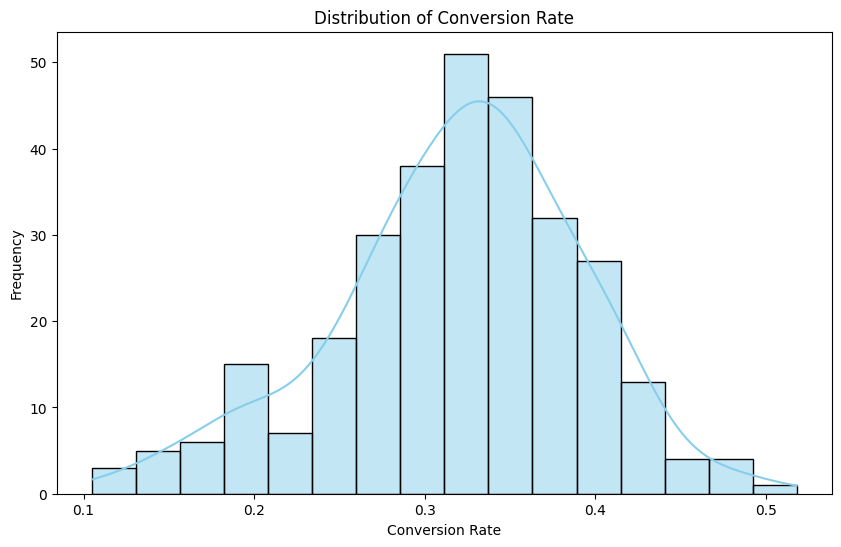

In [20]:
# Plot 1: Distribution of Conversion Rate
plt.figure(figsize=(10, 6))
sns.histplot(df['conversion_rate'], kde=True, color='skyblue')
plt.title('Distribution of Conversion Rate')
plt.xlabel('Conversion Rate')
plt.ylabel('Frequency')
plt.show()

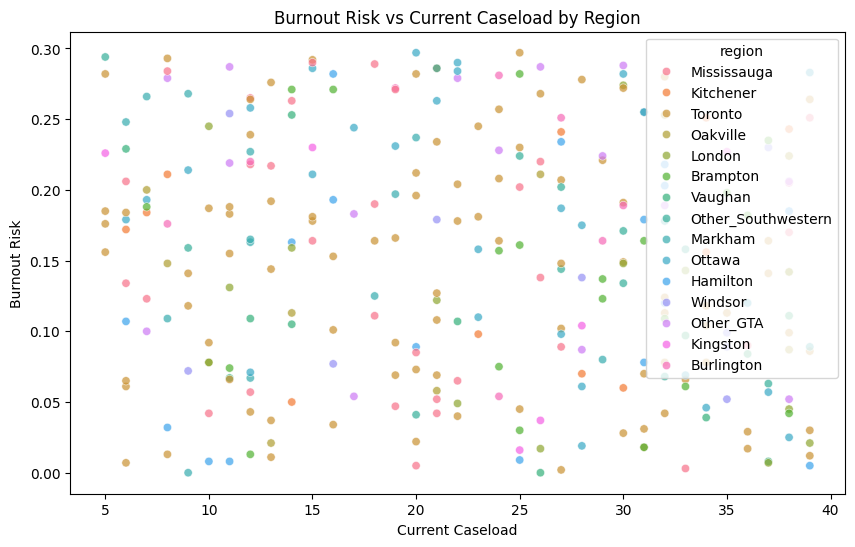

In [21]:
# Plot 2: Burnout Risk vs Current Caseload
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='current_caseload', y='burnout_risk', hue='region', alpha=0.7)
plt.title('Burnout Risk vs Current Caseload by Region')
plt.xlabel('Current Caseload')
plt.ylabel('Burnout Risk')
plt.show()

/tmp/ipykernel_15302/396008491.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='region', y='csat_score', palette='Set3')


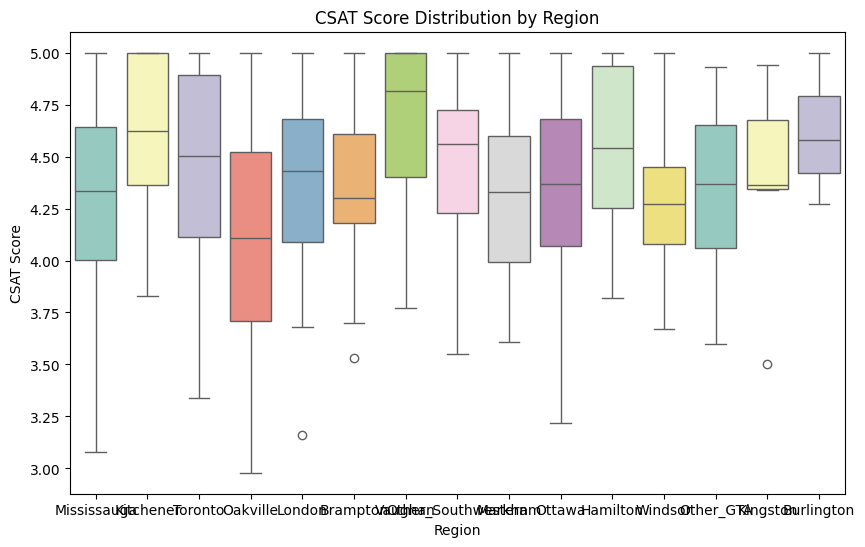

In [25]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='region', y='csat_score', palette='Set3')
plt.title('CSAT Score Distribution by Region')
plt.xlabel('Region')
plt.ylabel('CSAT Score')
plt.show()

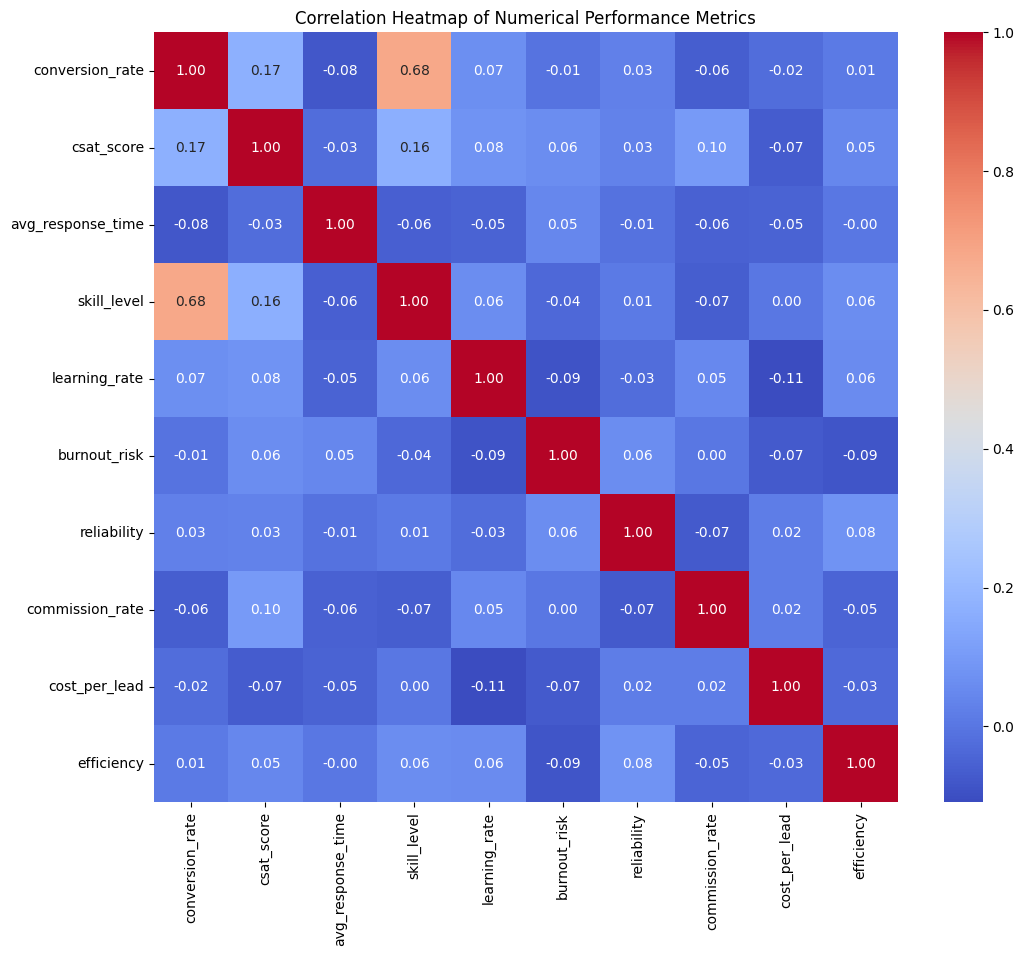

In [28]:
# Plot 4: Correlation Matrix of Numerical Features
plt.figure(figsize=(12, 10))
corr = df[numerical_columns].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Performance Metrics')
plt.show()


/tmp/ipykernel_15302/803236534.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_eff.index, y=region_eff.values, palette='viridis')


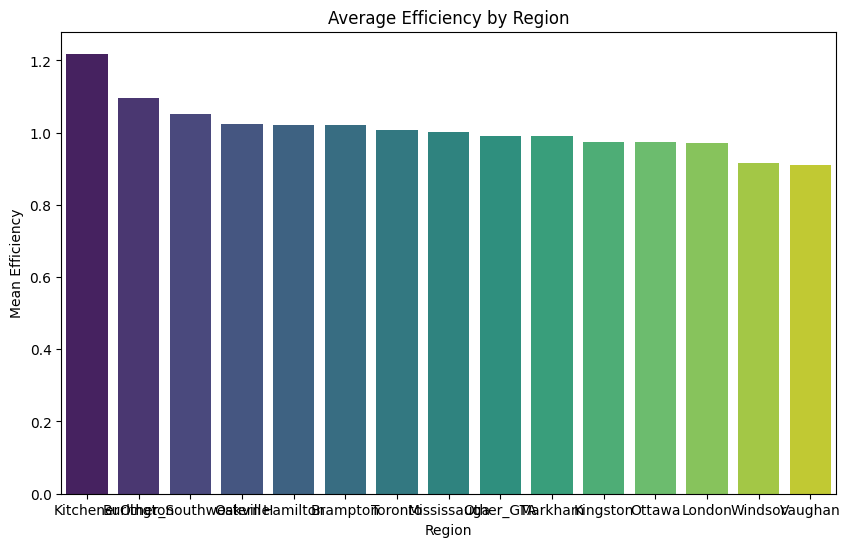

In [29]:
#Average Efficiency by Region (Bar Chart)
plt.figure(figsize=(10, 6))
region_eff = df.groupby('region')['efficiency'].mean().sort_values(ascending=False)
sns.barplot(x=region_eff.index, y=region_eff.values, palette='viridis')
plt.title('Average Efficiency by Region')
plt.xlabel('Region')
plt.ylabel('Mean Efficiency')
plt.show()